# Task 2: ARIMA Model for TSLA

## Build and evaluate ARIMA model for Tesla stock price prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')

# Load TSLA data
df = pd.read_csv('../data/processed/TSLA_data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

print(f'Loaded {len(df)} rows of TSLA data')
df.head()

Loaded 2999 rows of TSLA data


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-01,50.683387,51.173007,50.222982,50.781110,50.781110,34910882
2015-01-02,50.924379,51.379623,50.138026,50.891265,50.891265,11185296
2015-01-05,51.650017,52.019852,51.336807,51.643422,51.643422,3714636
2015-01-06,53.457586,54.448408,53.332674,53.579574,53.579574,11960895
2015-01-07,54.061873,54.832691,53.485078,53.931365,53.931365,28796869


In [2]:
# Use closing prices
series = df['Close']

# Split into train and test (chronological)
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

print(f'Training set: {len(train)} rows')
print(f'Test set: {len(test)} rows')
print(f'Train period: {train.index.min()} to {train.index.max()}')
print(f'Test period: {test.index.min()} to {test.index.max()}')

Training set: 2399 rows
Test set: 600 rows
Train period: 2015-01-01 00:00:00 to 2024-03-12 00:00:00
Test period: 2024-03-13 00:00:00 to 2026-06-30 00:00:00


In [5]:
# Fit ARIMA model with (p,d,q) = (1,1,1)
model = ARIMA(train, order=(1,1,1))
fitted_model = model.fit()

print(fitted_model.summary())

C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2399
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -11058.744
Date:                Mon, 06 Jul 2026   AIC                          22123.487
Time:                        23:56:28   BIC                          22140.835
Sample:                    01-01-2015   HQIC                         22129.799
                         - 03-12-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2160      0.044      4.926      0.000       0.130       0.302
ma.L1          0.0515      0.044      1.161      0.246      -0.035       0.139
sigma2       593.1207      6.909     85.854      0.0

In [6]:
# Generate predictions
predictions = fitted_model.forecast(len(test))

# Calculate metrics
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = np.mean(np.abs((test - predictions) / test)) * 100

print(f'ARIMA(1,1,1) Performance:')
print(f'  MAE: ${mae:.2f}')
print(f'  RMSE: ${rmse:.2f}')
print(f'  MAPE: {mape:.2f}%')

ARIMA(1,1,1) Performance:
  MAE: $2202.47
  RMSE: $2571.31
  MAPE: 44.98%


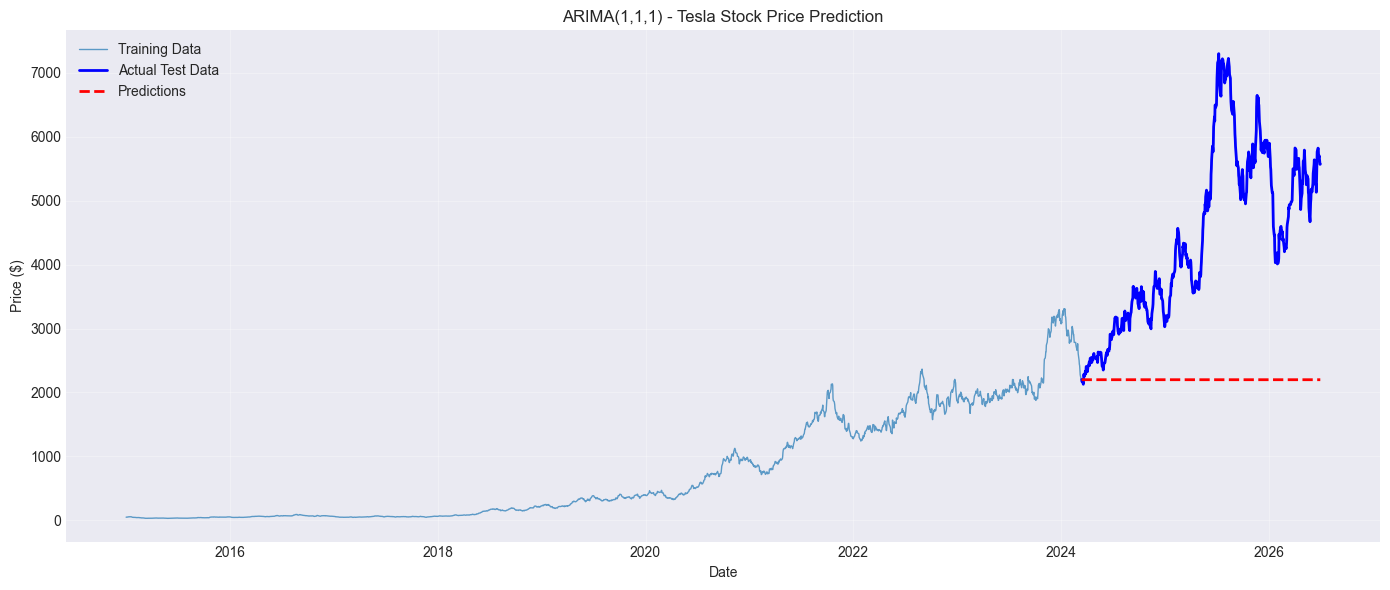

In [7]:
# Plot results
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label='Training Data', linewidth=1, alpha=0.7)
ax.plot(test.index, test, label='Actual Test Data', linewidth=2, color='blue')
ax.plot(test.index, predictions, label='Predictions', linewidth=2, linestyle='--', color='red')
ax.set_title('ARIMA(1,1,1) - Tesla Stock Price Prediction')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Try different ARIMA orders
orders = [(1,1,1), (2,1,2), (3,1,2)]
results = []

for order in orders:
    try:
        model = ARIMA(train, order=order)
        fitted = model.fit()
        pred = fitted.forecast(len(test))
        
        mae = mean_absolute_error(test, pred)
        rmse = np.sqrt(mean_squared_error(test, pred))
        mape = np.mean(np.abs((test - pred) / test)) * 100
        
        results.append({
            'order': order,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'AIC': fitted.aic
        })
        print(f'ARIMA{order}: MAE=${mae:.2f}, RMSE=${rmse:.2f}, MAPE={mape:.2f}%, AIC={fitted.aic:.2f}')
    except:
        print(f'ARIMA{order}: Failed to converge')

# Find best model
if results:
    best = min(results, key=lambda x: x['RMSE'])
    print(f'Best model: ARIMA{best["order"]} with RMSE=${best["RMSE"]:.2f}')

C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


ARIMA(1, 1, 1): MAE=$2202.47, RMSE=$2571.31, MAPE=44.98%, AIC=22123.49


C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


ARIMA(2, 1, 2): MAE=$2193.79, RMSE=$2563.75, MAPE=44.77%, AIC=22122.36


C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\dell\Documents\GitHub\portfolio-optimization\venv_working\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


ARIMA(3, 1, 2): MAE=$2194.98, RMSE=$2564.79, MAPE=44.80%, AIC=22119.15
Best model: ARIMA(2, 1, 2) with RMSE=$2563.75
